In [12]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import resample
from agents.ffnn_agent2 import FFNNAgent
from torch.utils.data import TensorDataset, DataLoader
import torch
import matplotlib.pyplot as plt
import random
import os
import json
from itertools import cycle
from typing import List, Dict

In [13]:
import re
from pathlib import Path

# ---------- Helpers ----------

def is_seed_dir(p: Path) -> bool:
    return (
        p.is_dir()
        and p.name.startswith("seed_")
        and (p / "metrics.csv").is_file()
        and (p / "meta.json").is_file()
    )

def is_experiment_dir(p: Path) -> bool:
    if not p.is_dir():
        return False
    return any(is_seed_dir(d) for d in p.iterdir())

# Regex to extract PCA, minID, majID, BIAS
CORE_RE = re.compile(
    r"PCA(?P<pca>\d+).*?minID(?P<min>\d+).*?majID(?P<maj>\d+).*?BIAS(?P<bias>[0-9.]+)",
    re.IGNORECASE,
)

def make_short_label(exp_name: str) -> str:
    """
    Extract PCA, minID, majID, bias from a folder name.
    Return a short readable label like:
        PCA4_min1_maj0_bias0.35
    """
    m = CORE_RE.search(exp_name)
    if not m:
        # fallback: return the core part without DATE
        core = exp_name.split("_DATE")[0]
        return core

    pca = m.group("pca")
    min_id = m.group("min")
    maj_id = m.group("maj")
    bias = m.group("bias")

    return f"PCA{pca}_min{min_id}_maj{maj_id}_bias{bias}"

# ---------- Main Generator ----------

def generate_experiment_labels_dict():
    training_root = Path("training_runs_drac/training_runs")
    if not training_root.is_dir():
        print("[error] training_runs/ does not exist.")
        return

    exp_dirs = sorted(
        [d for d in training_root.iterdir() if is_experiment_dir(d)],
        key=lambda p: p.name,
    )

    if not exp_dirs:
        print("[info] No experiment folders found.")
        return

    print("\n# ================= GENERATED EXPERIMENT_LABELS =================")
    print("EXPERIMENT_LABELS = {")
    for d in exp_dirs:
        short = make_short_label(d.name)
        print(f'    "{d.name}": "{short}",')
    print("}")
    print("# ==============================================================\n")

# Run immediately
generate_experiment_labels_dict()



# ================= GENERATED EXPERIMENT_LABELS =================
EXPERIMENT_LABELS = {
    "SPECcreditLambda06_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_BIAS0.35_GG202601131946_e0191cff": "PCA10_min1_maj0_bias0.35",
    "SPECcredit_nopca_nobias_1phase_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202602172136_b1297bb8": "SPECcredit_nopca_nobias_1phase_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202602172136_b1297bb8",
    "SPECcredit_nopca_nobias_2phase_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202602172138_cef46567": "SPECcredit_nopca_nobias_2phase_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202602172138_cef46567",
    "SPECpamap2_nopca_nobias_1phase_EP6000_PCA6_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202602172204_9f221945": "SPECpamap2_nopca_nobias_1phase_EP6000_PCA6_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202602172204_9f221945",
    "SPECpamap2_nopca_nobias_2phase_EP6000_PCA6_REWfairness_minID1_majID0_

[info] Using 2 experiment folders from EXPERIMENT_LABELS.
[info] Discovered 31 numeric time-series metrics to plot.


/tmp/ipykernel_42136/3396917459.py:471: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


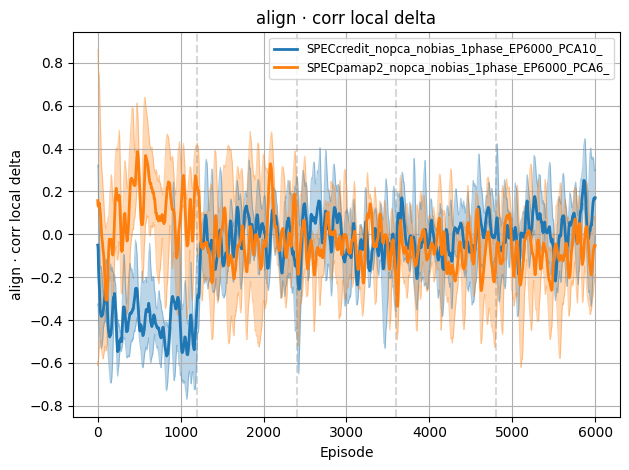

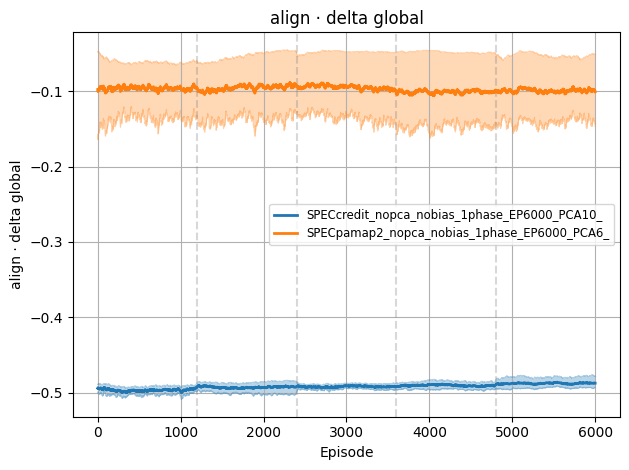

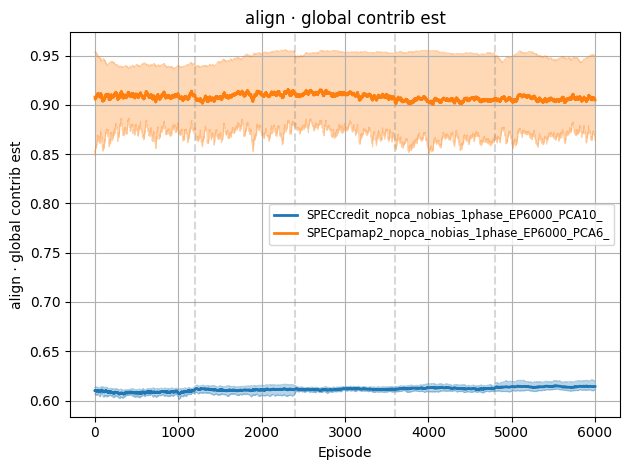

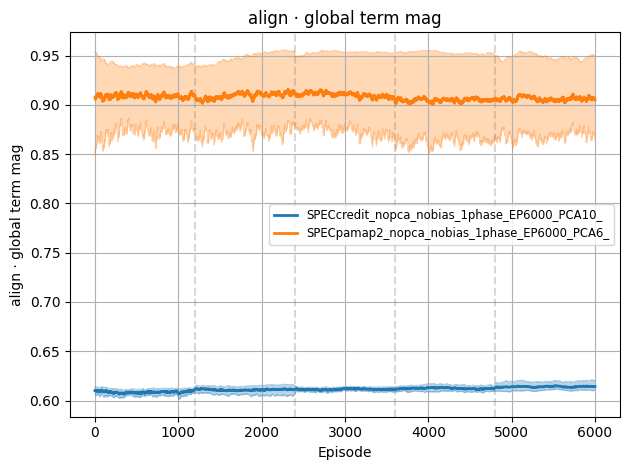

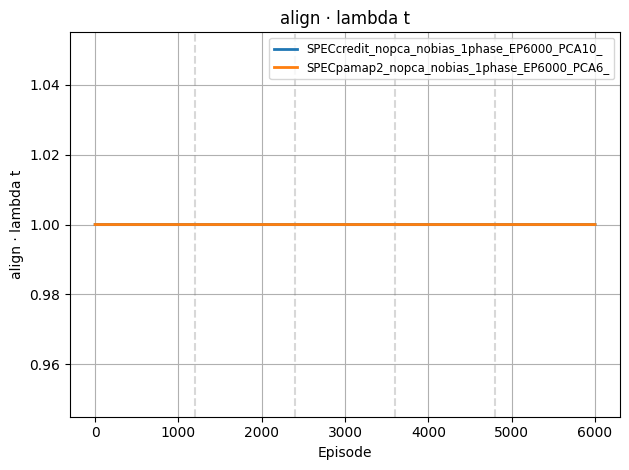

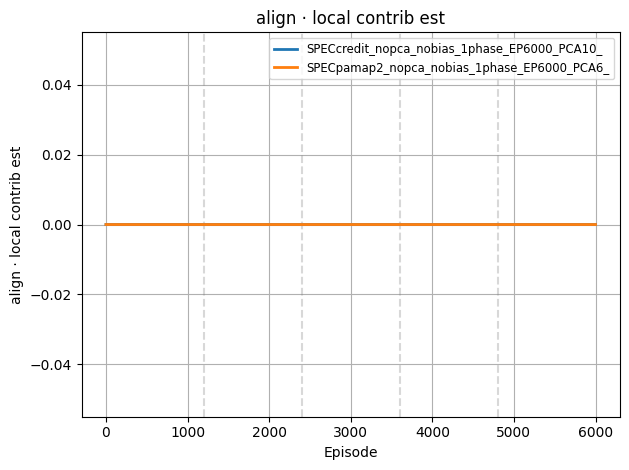

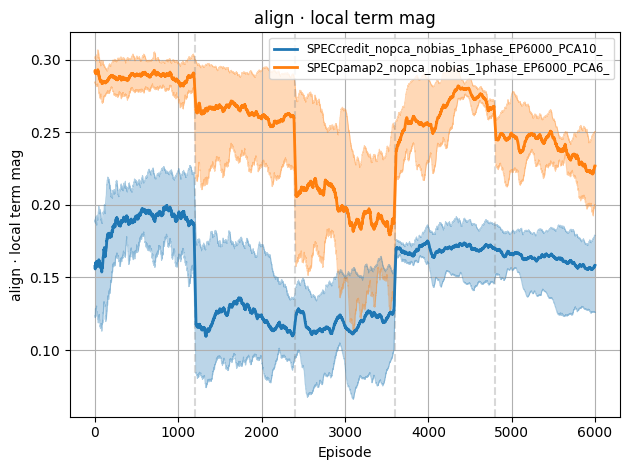

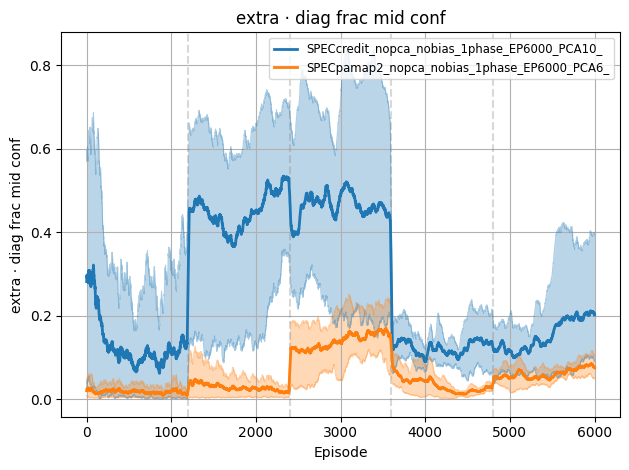

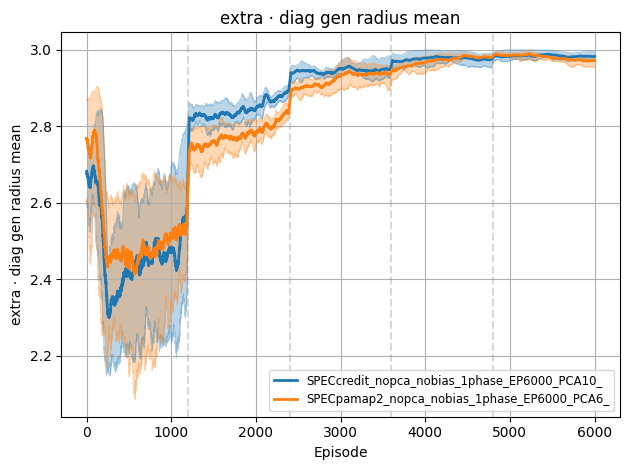

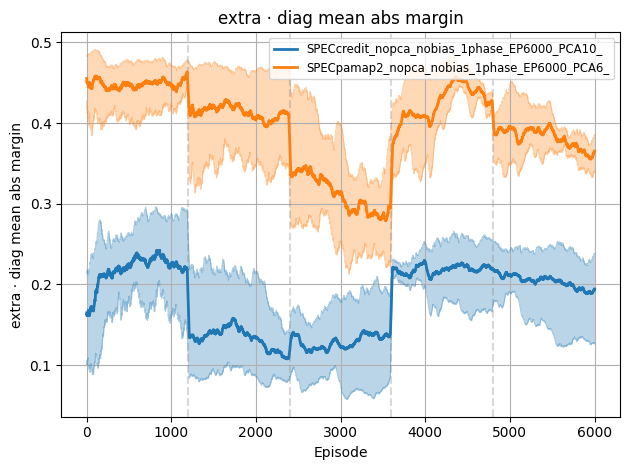

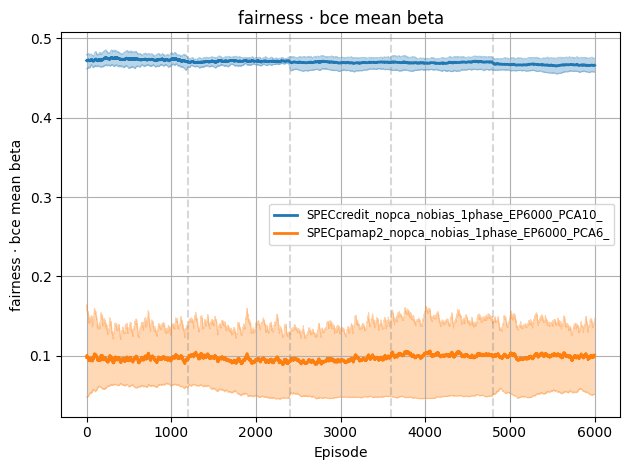

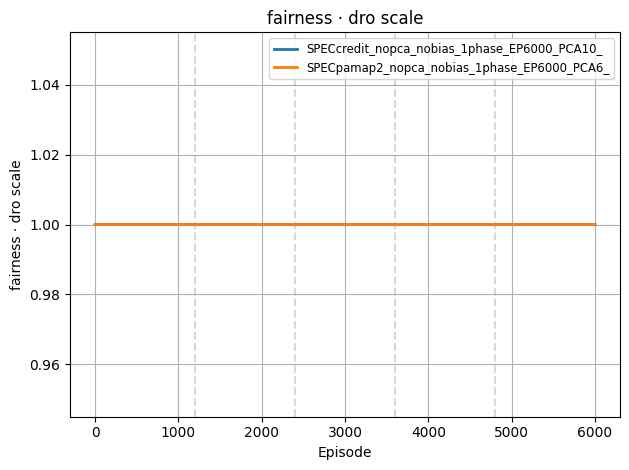

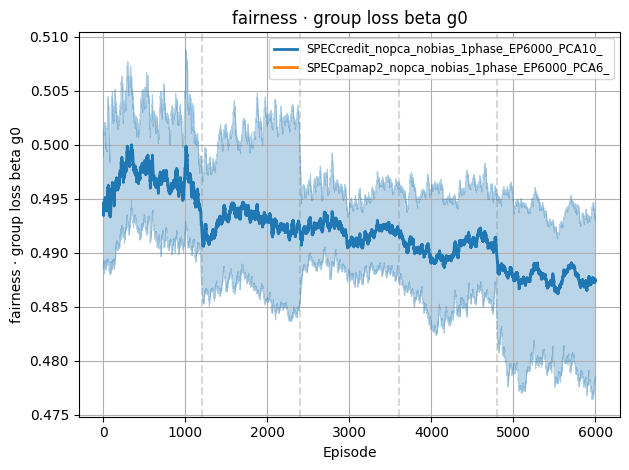

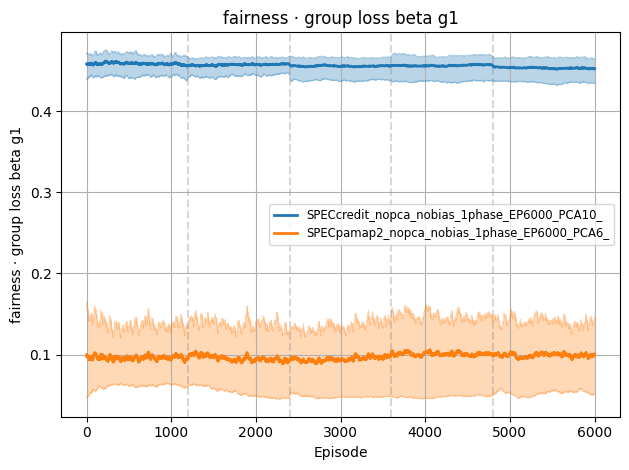

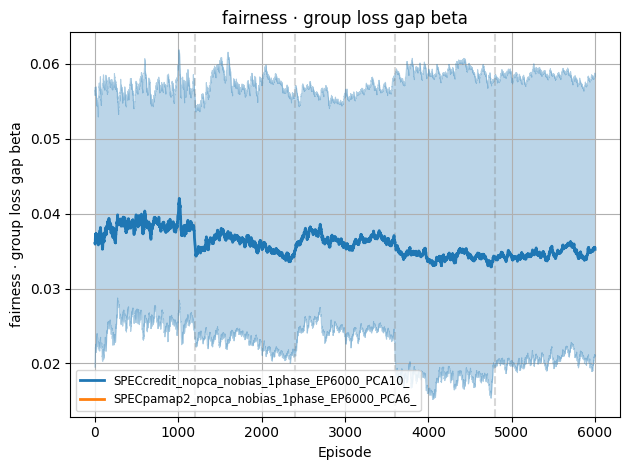

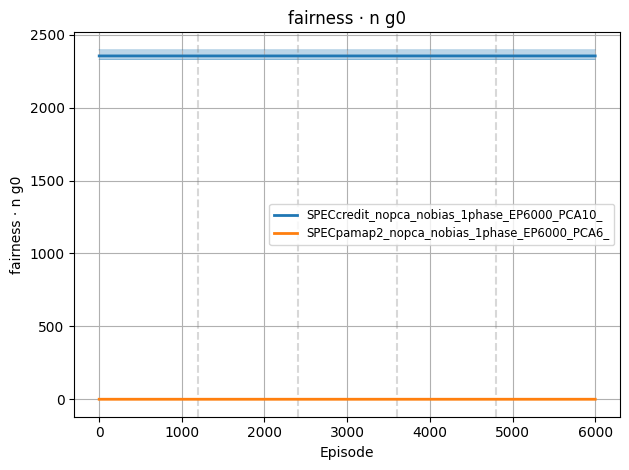

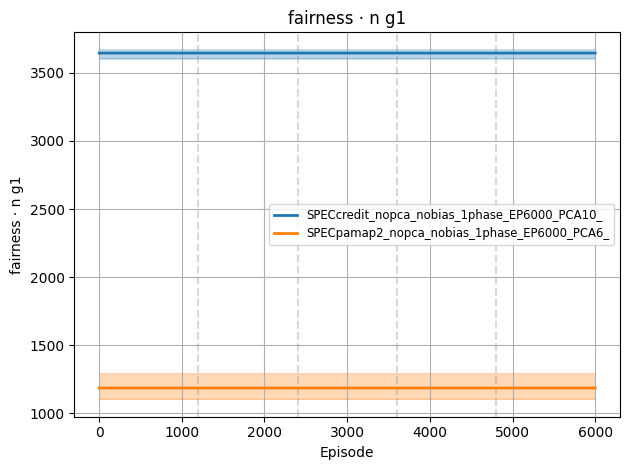

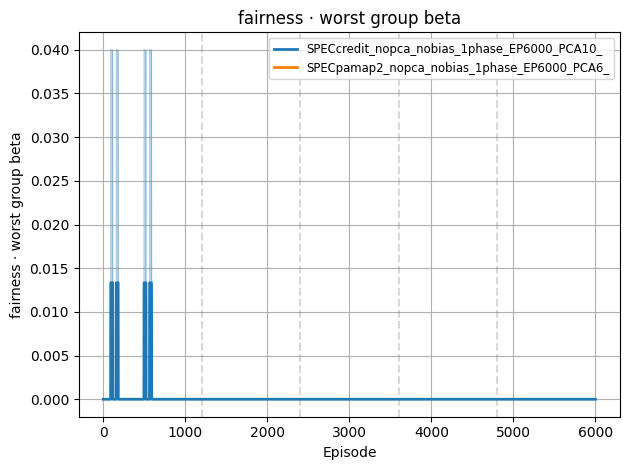

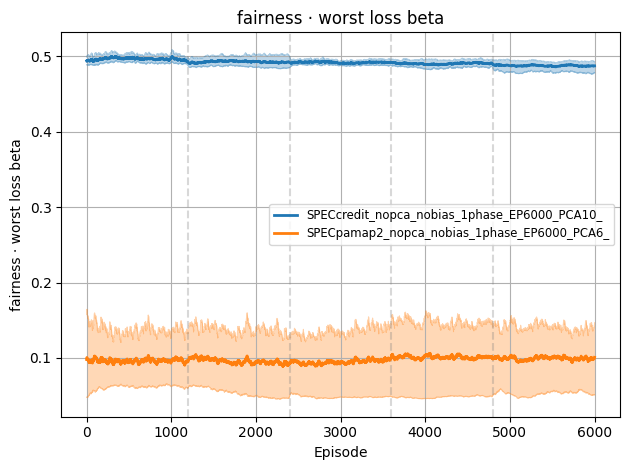

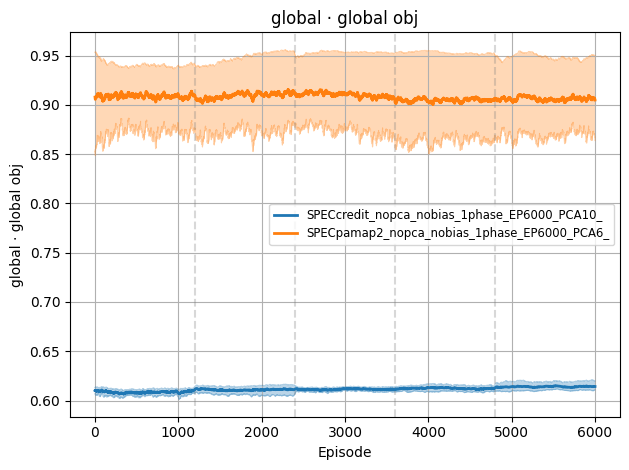

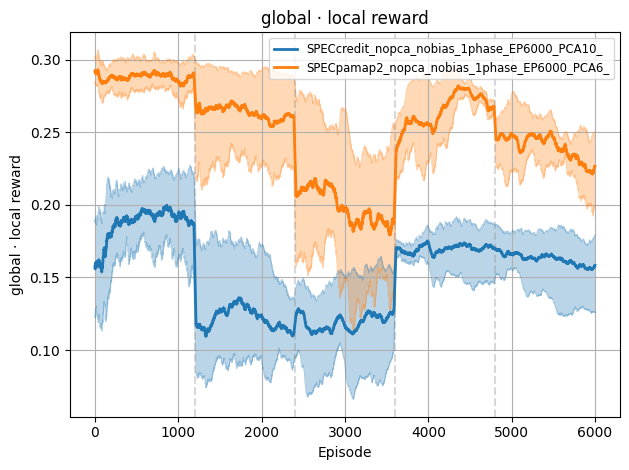

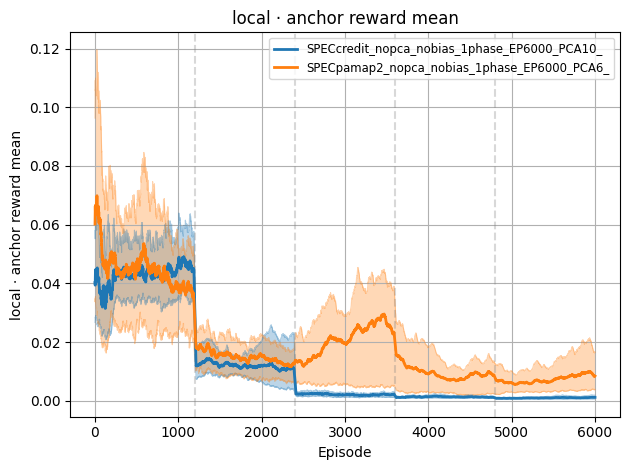

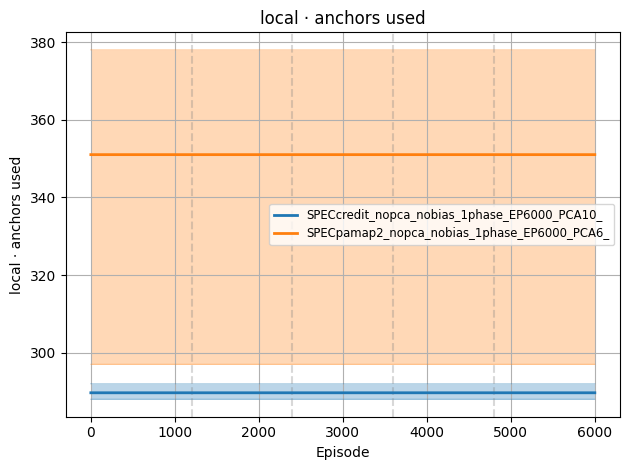

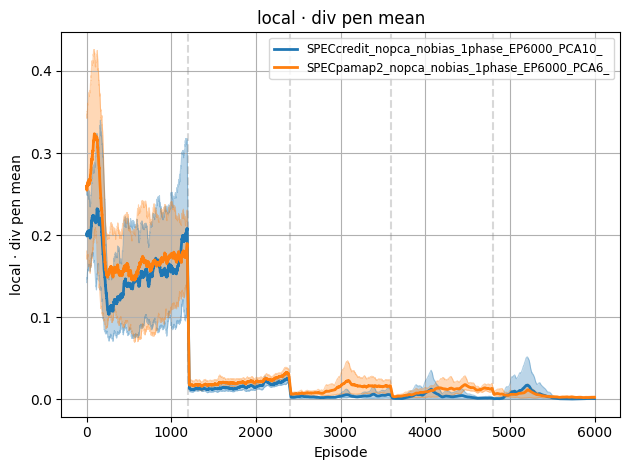

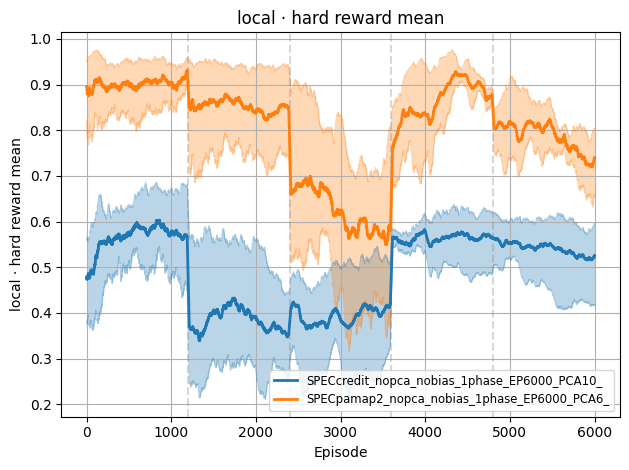

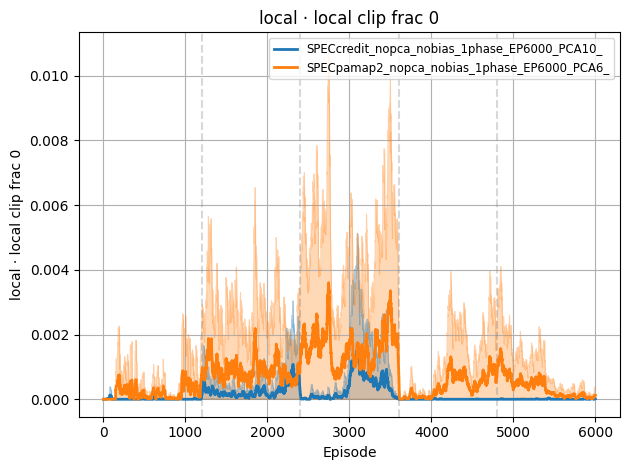

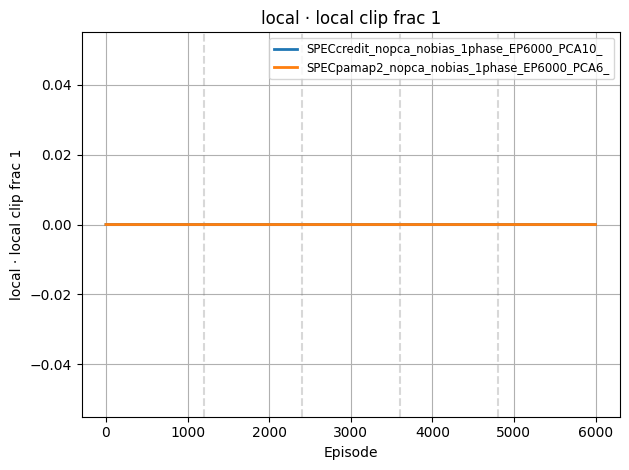

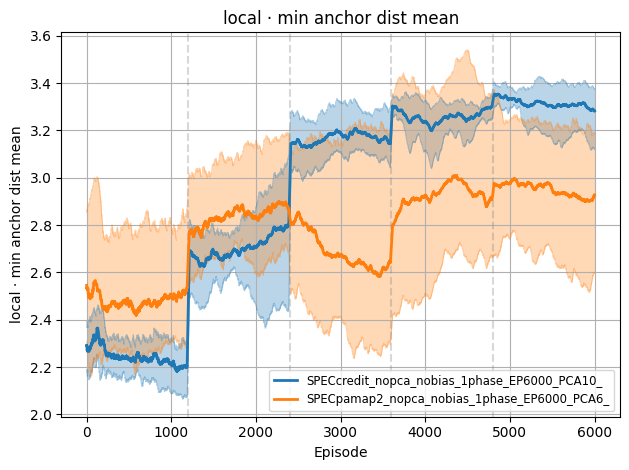

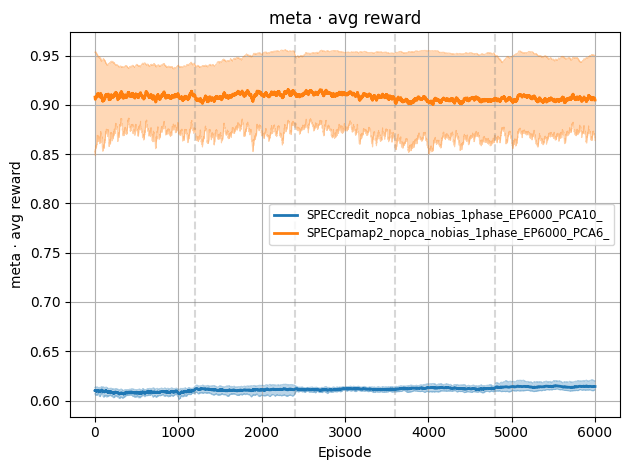

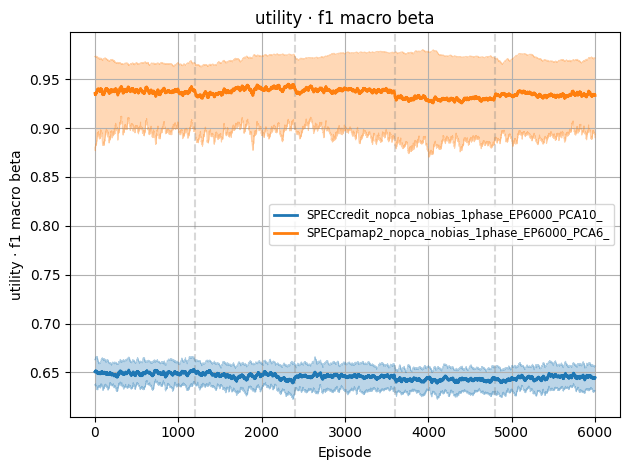

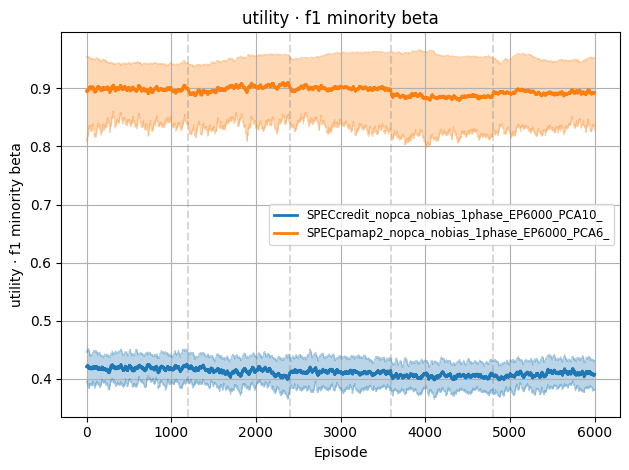

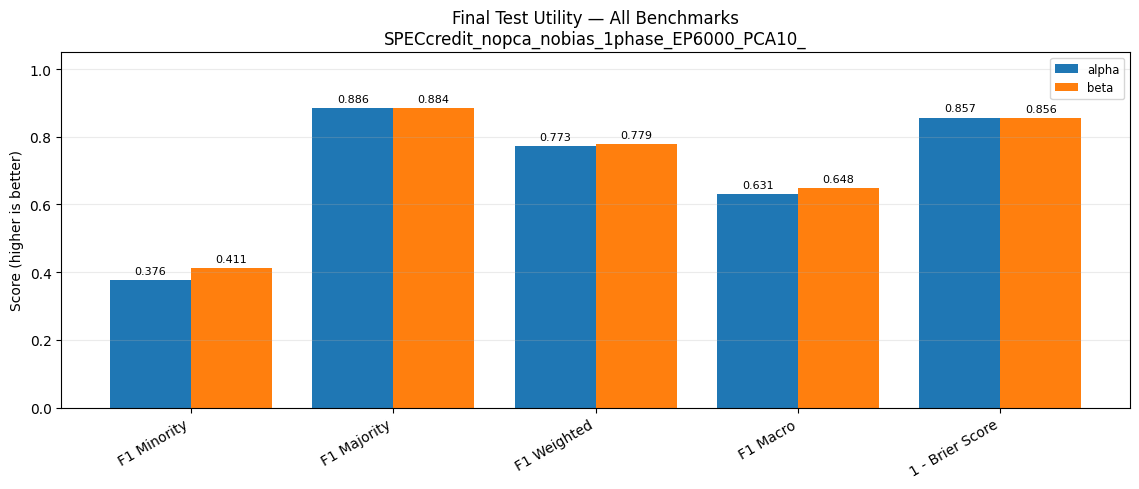

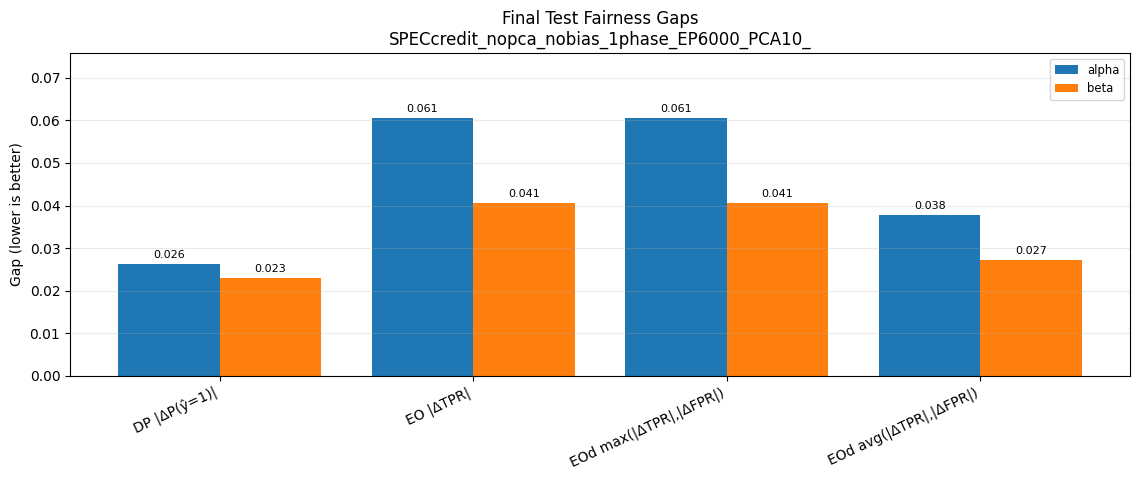

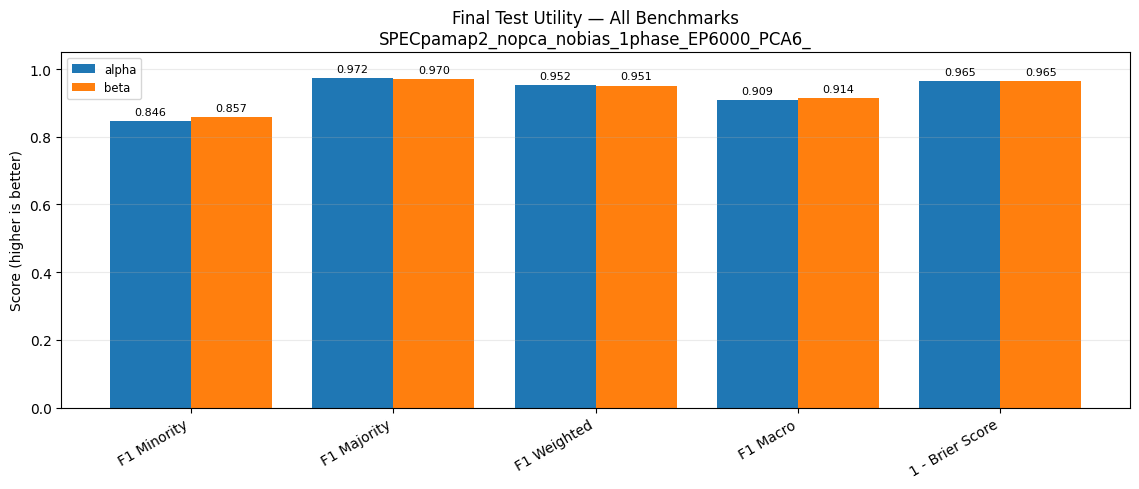

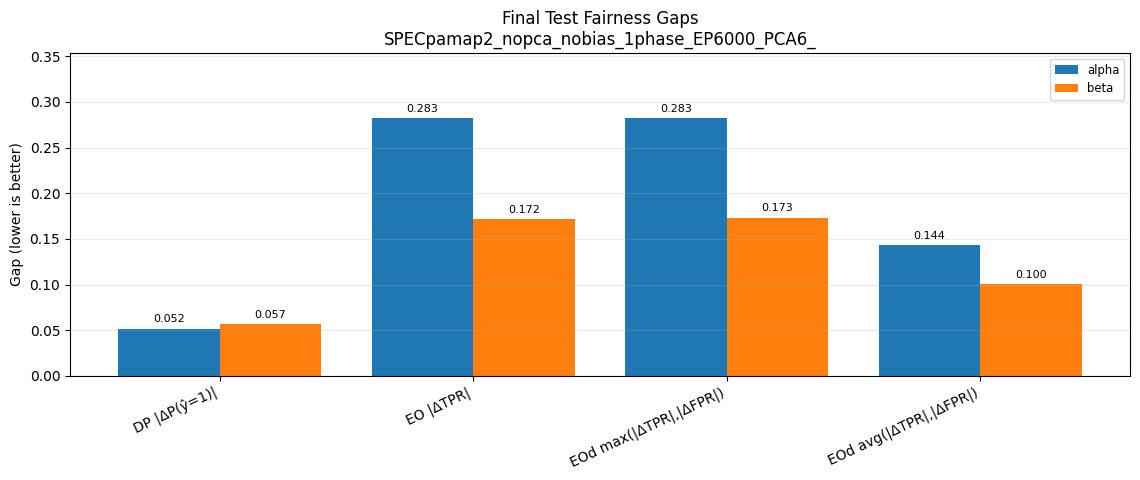

In [14]:
"""
Drop-in plotting script for training_runs/

What it does:
1) Auto-discovers ALL numeric time-series metrics in seed_*/metrics.csv and plots them.
   - Easy toggles at top to include/exclude prefixes or specific columns.
2) For each experiment, creates TWO final bar plots from final_test_metrics.csv:
   - Utility (F1s + 1-Brier): Alpha vs Beta vs (optional) CTGAN/CTAB/etc if present
   - Fairness gaps (DP / EO / EOd): Alpha vs Beta (and optional baselines if present)

Run from project root:
  python plot_metrics.py
"""

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("training_runs_drac/training_runs")

# ============================================================
# 0) QUICK TOGGLES (comment out what you don't want)
# ============================================================
PLOT_TIME_SERIES = True
PLOT_FINAL_BARS_UTILITY = True
PLOT_FINAL_BARS_FAIRNESS = True
SHOW_CURRICULUM_LINES = True

SMOOTH_WINDOW = 25  # set to 1 or None to disable smoothing

# --- easiest way to control which time-series get plotted ---
# Option A (recommended): choose prefixes (everything starting with these)
TIME_SERIES_INCLUDE_PREFIXES = [
    "meta", "global", "utility", "fairness", "local", "extra", "align"
]
# Example:
# TIME_SERIES_INCLUDE_PREFIXES = ["meta", "global", "utility"]

# Option B: additionally blacklist specific columns (even if prefix is included)
TIME_SERIES_EXCLUDE_COLS = {
    "wall_seconds",
    "align.reward_mode",  # usually string
}

# If you prefer plotting ONLY a few specific columns, set this to a non-empty list:
# (when non-empty, it overrides prefix logic)
TIME_SERIES_ONLY_COLS = [
    # "meta.avg_reward",
    # "global.global_obj",
    # "utility.f1_minority_beta",
]

# Column name for curriculum stage (vertical lines)
STAGE_COL = "align.curriculum_stage"

# ============================================================
# 1) SELECT WHICH EXPERIMENTS TO PLOT
# ============================================================
# If empty {}, script auto-discovers all valid experiment folders.
EXPERIMENT_LABELS = {
    "SPECcredit_nopca_nobias_1phase_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202602172136_b1297bb8": "SPECcredit_nopca_nobias_1phase_EP6000_PCA10_",
    "SPECpamap2_nopca_nobias_1phase_EP6000_PCA6_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202602172204_9f221945": "SPECpamap2_nopca_nobias_1phase_EP6000_PCA6_",
}

# ---------------------------------------------------------------------
# Helpers to identify experiment + seed folders
# ---------------------------------------------------------------------
def is_seed_dir(p: Path) -> bool:
    return (
        p.is_dir()
        and p.name.startswith("seed_")
        and (p / "metrics.csv").is_file()
        and (p / "meta.json").is_file()
    )

def is_experiment_dir(p: Path) -> bool:
    if not p.is_dir():
        return False
    seeds = [d for d in p.iterdir() if is_seed_dir(d)]
    return len(seeds) > 0

# ---------------------------------------------------------------------
# Parse experiment name (for auto labels if needed)
# ---------------------------------------------------------------------
CORE_RE = re.compile(
    r"^EP(?P<episodes>\d+)_"
    r"PCA(?P<pca>\d+)_"
    r"REW(?P<rew>.+?)_"
    r"minID(?P<min>\d+)_"
    r"majID(?P<maj>\d+)_"
    r"TRJ(?P<trj>\d+)_"
    r"REAL(?P<real>\d+)_"
    r"BIAS(?P<bias>[0-9.]+)"
)

def split_core_and_tail(name: str):
    if "_DATE" in name:
        core, tail = name.split("_DATE", 1)
        return core, tail
    return name, ""

def parse_experiment_name(name: str):
    core, _ = split_core_and_tail(name)
    m = CORE_RE.match(core)
    if not m:
        return {"core": core}
    d = m.groupdict()
    d["core"] = core
    for k in ("episodes", "pca", "min", "maj", "trj", "real"):
        d[k] = int(d[k])
    d["bias"] = float(d["bias"])
    return d

def make_auto_label(info: dict) -> str:
    if not info:
        return "unknown"
    return (
        f"PCA{info.get('pca', '?')}_"
        f"min{info.get('min', '?')}_"
        f"maj{info.get('maj', '?')}_"
        f"bias{info.get('bias', '?')}"
    )

def label_for_folder(folder_name: str, info: dict) -> str:
    if folder_name in EXPERIMENT_LABELS:
        return EXPERIMENT_LABELS[folder_name]
    return make_auto_label(info)

# ---------------------------------------------------------------------
# Training metrics (metrics.csv)
# ---------------------------------------------------------------------
def load_seed_metrics(seed_dir: Path) -> pd.DataFrame | None:
    try:
        df = pd.read_csv(seed_dir / "metrics.csv")
    except Exception as e:
        print(f"[warn] Could not read {seed_dir / 'metrics.csv'}: {e}")
        return None

    if "episode" not in df.columns:
        print(f"[warn] No 'episode' column in {seed_dir / 'metrics.csv'}, skipping this seed.")
        return None

    return df.copy()

def load_experiment_metrics_all_seeds(exp_dir: Path) -> pd.DataFrame | None:
    seed_dirs = [d for d in exp_dir.iterdir() if is_seed_dir(d)]
    if not seed_dirs:
        print(f"[info] No seeds found in {exp_dir}, skipping training curves.")
        return None

    dfs = []
    for sd in seed_dirs:
        df = load_seed_metrics(sd)
        if df is not None and not df.empty:
            df["seed"] = sd.name
            dfs.append(df)

    if not dfs:
        print(f"[info] All seeds in {exp_dir} unreadable/empty, skipping training curves.")
        return None

    all_df = pd.concat(dfs, ignore_index=True)
    all_df = all_df.sort_values(["episode", "seed"]).reset_index(drop=True)
    return all_df

# ---------------------------------------------------------------------
# Final test metrics (final_test_metrics.csv)
# ---------------------------------------------------------------------
def aggregate_final_metrics_for_experiment(exp_dir: Path) -> pd.Series | None:
    path = exp_dir / "final_test_metrics.csv"
    if not path.is_file():
        print(f"[info] No final_test_metrics.csv found in {exp_dir.name}, skipping final bars.")
        return None

    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[warn] Could not read {path}: {e}")
        return None

    if df.empty:
        print(f"[info] final_test_metrics.csv is empty for {exp_dir.name}.")
        return None

    return df.mean(numeric_only=True)

def smooth_agg_df(agg: pd.DataFrame, window: int | None) -> pd.DataFrame:
    if window is None or window <= 1:
        return agg
    agg = agg.sort_values("episode").reset_index(drop=True)
    for col in ("mean", "min", "max"):
        if col in agg.columns:
            agg[col] = agg[col].rolling(window=window, center=True, min_periods=1).mean()
    return agg

# ============================================================
# Time-series discovery + labeling
# ============================================================
def _prefix_of(col: str) -> str:
    return col.split(".", 1)[0] if "." in col else col

def discover_time_series_metrics(seed_cache: dict[str, pd.DataFrame]) -> list[str]:
    """
    Union all numeric metric columns across all experiments (excluding episode/seed/stage),
    then filter using TIME_SERIES_ONLY_COLS or prefix include/exclude lists.
    """
    all_cols = set()
    for _exp, df in seed_cache.items():
        for c in df.columns:
            if c in ("episode", "seed", STAGE_COL):
                continue
            if c in TIME_SERIES_EXCLUDE_COLS:
                continue
            if pd.api.types.is_numeric_dtype(df[c]):
                all_cols.add(c)

    # override: explicit list
    if TIME_SERIES_ONLY_COLS:
        wanted = []
        for c in TIME_SERIES_ONLY_COLS:
            if c in all_cols:
                wanted.append(c)
            else:
                print(f"[warn] TIME_SERIES_ONLY_COLS requested '{c}' but it wasn't found as numeric anywhere.")
        return wanted

    cols = sorted(all_cols)

    if TIME_SERIES_INCLUDE_PREFIXES:
        inc = set(TIME_SERIES_INCLUDE_PREFIXES)
        cols = [c for c in cols if _prefix_of(c) in inc]

    cols = sorted(cols, key=lambda c: (_prefix_of(c), c))
    return cols

def pretty_metric_label(col: str) -> str:
    return col.replace(".", " · ").replace("_", " ")

# ============================================================
# FINAL BAR PLOTS
# ============================================================
def _annotate(ax_, rects):
    for r in rects:
        h = r.get_height()
        if np.isfinite(h):
            ax_.annotate(
                f"{h:.3f}",
                xy=(r.get_x() + r.get_width() / 2, h),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8
            )

def _discover_prefixes_for_utility(mean_series: pd.Series) -> list[str]:
    """
    Finds prefixes that have the standard utility suffixes in final_test_metrics.csv:
      <prefix>_f1_minority, _f1_majority, _f1_weighted, _f1_macro, _brier
    e.g. alpha, beta, alphaCT, alphaCTAB, oversample, undersample, jitter, ...
    """
    prefixes = set()
    for col in mean_series.index:
        if not isinstance(col, str):
            continue
        m = re.match(r"^(?P<prefix>.+?)_(f1_minority|f1_majority|f1_weighted|f1_macro|brier)$", col)
        if m:
            prefixes.add(m.group("prefix"))

    preferred = ["alpha", "beta", "alphaCT", "alphaCTAB", "oversample", "undersample", "jitter"]
    ordered = [p for p in preferred if p in prefixes] + sorted([p for p in prefixes if p not in preferred])
    return ordered

def plot_final_utility_bars(exp_label: str, mean_series: pd.Series):
    categories = [
        ("f1_minority", "F1 Minority"),
        ("f1_majority", "F1 Majority"),
        ("f1_weighted", "F1 Weighted"),
        ("f1_macro",    "F1 Macro"),
        ("brier",       "1 - Brier Score"),
    ]

    prefixes = _discover_prefixes_for_utility(mean_series)
    if not prefixes:
        print(f"[info] No utility prefix metrics found for {exp_label}. Skipping utility bars.")
        return None

    vals = []
    for p in prefixes:
        row = []
        for suf, _lbl in categories:
            key = f"{p}_{suf}"
            v = mean_series.get(key, np.nan)
            if suf == "brier" and np.isfinite(v):
                v = 1.0 - float(v)
            row.append(float(v) if v is not None else np.nan)
        vals.append(row)
    vals = np.array(vals, dtype=float)

    if np.all(np.isnan(vals)):
        print(f"[info] Utility bars all-NaN for {exp_label}. Skipping.")
        return None

    x = np.arange(len(categories))
    n = len(prefixes)
    group_width = 0.80
    bar_w = group_width / max(n, 1)
    offsets = (np.arange(n) - (n - 1) / 2.0) * bar_w

    fig, ax = plt.subplots(figsize=(11.5, 5))
    for i, p in enumerate(prefixes):
        bars = ax.bar(x + offsets[i], vals[i], bar_w, label=p)
        _annotate(ax, bars)

    ax.set_ylabel("Score (higher is better)")
    ax.set_title(f"Final Test Utility — All Benchmarks\n{exp_label}")
    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _s, lbl in categories], rotation=30, ha="right")
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(fontsize="small")
    fig.tight_layout()
    return fig

def _discover_prefixes_for_fairness(mean_series: pd.Series) -> list[str]:
    """
    Finds prefixes that have fairness columns in final_test_metrics.csv.
    Required at least dp_diff or eo_tpr_diff (we'll plot what exists).
    Typically alpha_*, beta_*.
    """
    prefixes = set()
    for col in mean_series.index:
        if not isinstance(col, str) or "_" not in col:
            continue
        # match alpha_dp_diff, beta_eod_avg_diff, etc.
        m = re.match(r"^(?P<prefix>.+?)_(dp_diff|eo_tpr_diff|eod_max_diff|eod_avg_diff)$", col)
        if m:
            prefixes.add(m.group("prefix"))

    preferred = ["alpha", "beta", "alphaCT", "alphaCTAB", "oversample", "undersample", "jitter"]
    ordered = [p for p in preferred if p in prefixes] + sorted([p for p in prefixes if p not in preferred])
    return ordered

def plot_final_fairness_bars(exp_label: str, mean_series: pd.Series):
    fairness_metrics = [
        ("dp_diff",      "DP |ΔP(ŷ=1)|"),
        ("eo_tpr_diff",  "EO |ΔTPR|"),
        ("eod_max_diff", "EOd max(|ΔTPR|,|ΔFPR|)"),
        ("eod_avg_diff", "EOd avg(|ΔTPR|,|ΔFPR|)"),
    ]

    prefixes = _discover_prefixes_for_fairness(mean_series)
    if not prefixes:
        print(f"[info] No fairness columns found for {exp_label}. Skipping fairness bars.")
        return None

    # Build values: rows=prefixes, cols=fairness_metrics
    vals = []
    for p in prefixes:
        row = []
        for suf, _lbl in fairness_metrics:
            row.append(float(mean_series.get(f"{p}_{suf}", np.nan)))
        vals.append(row)
    vals = np.array(vals, dtype=float)

    if np.all(np.isnan(vals)):
        print(f"[info] Fairness bars all-NaN for {exp_label}. Skipping.")
        return None

    x = np.arange(len(fairness_metrics))
    n = len(prefixes)
    group_width = 0.80
    bar_w = group_width / max(n, 1)
    offsets = (np.arange(n) - (n - 1) / 2.0) * bar_w

    fig, ax = plt.subplots(figsize=(11.5, 4.9))
    for i, p in enumerate(prefixes):
        bars = ax.bar(x + offsets[i], vals[i], bar_w, label=p)
        _annotate(ax, bars)

    # scale y so tiny gaps are visible
    finite = vals[np.isfinite(vals)]
    ymax = 0.1 if finite.size == 0 else float(max(0.05, np.max(finite) * 1.25))

    ax.set_ylim(0.0, ymax)
    ax.set_ylabel("Gap (lower is better)")
    ax.set_title(f"Final Test Fairness Gaps\n{exp_label}")
    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _s, lbl in fairness_metrics], rotation=25, ha="right")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(fontsize="small")
    fig.tight_layout()
    return fig

# ---------------------------------------------------------------------
# Main plotting logic
# ---------------------------------------------------------------------
def main():
    if not ROOT.is_dir():
        print(f"[error] {ROOT} does not exist. Run this from the project root.")
        return

    # --- Decide which experiment folders to use ---
    if EXPERIMENT_LABELS:
        exp_dirs = []
        for folder_name in EXPERIMENT_LABELS.keys():
            p = ROOT / folder_name
            if not is_experiment_dir(p):
                print(f"[warn] {p} is not a valid experiment folder (missing seeds/metrics). Skipping.")
                continue
            exp_dirs.append(p)
        exp_dirs = sorted(exp_dirs, key=lambda p: p.name)
        print(f"[info] Using {len(exp_dirs)} experiment folders from EXPERIMENT_LABELS.")
    else:
        exp_dirs = [d for d in ROOT.iterdir() if is_experiment_dir(d)]
        exp_dirs = sorted(exp_dirs, key=lambda p: p.name)
        print(f"[info] Auto-discovered {len(exp_dirs)} experiment folders under {ROOT}.")

    if not exp_dirs:
        print("[info] No experiment folders selected/found. Nothing to plot.")
        return

    seed_cache: dict[str, pd.DataFrame] = {}
    info_cache: dict[str, dict] = {}
    final_cache: dict[str, pd.Series] = {}

    for exp_dir in exp_dirs:
        name = exp_dir.name
        info_cache[name] = parse_experiment_name(name)

        all_df = load_experiment_metrics_all_seeds(exp_dir)
        if all_df is not None:
            seed_cache[name] = all_df

        final_series = aggregate_final_metrics_for_experiment(exp_dir)
        if final_series is not None:
            final_cache[name] = final_series

    # ============================================================
    # Precompute curriculum stage transition episodes (across all runs)
    # ============================================================
    stage_transitions = []
    if SHOW_CURRICULUM_LINES:
        stage_set = set()
        for _name, df in seed_cache.items():
            if STAGE_COL not in df.columns:
                continue
            stage_by_ep = (
                df.groupby("episode")[STAGE_COL]
                .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
                .sort_index()
            )
            episodes = stage_by_ep.index.to_numpy()
            stages = stage_by_ep.to_numpy()
            for i in range(1, len(stages)):
                if stages[i] != stages[i - 1]:
                    stage_set.add(float(episodes[i]))
        stage_transitions = sorted(stage_set)

    # ============================================================
    # 1) Time-series plots (AUTO: discover all numeric metrics)
    # ============================================================
    if PLOT_TIME_SERIES:
        metric_cols = discover_time_series_metrics(seed_cache)
        print(f"[info] Discovered {len(metric_cols)} numeric time-series metrics to plot.")

        for metric_col in metric_cols:
            plt.figure()
            plotted_any = False
            metric_label = pretty_metric_label(metric_col)

            for exp_dir in exp_dirs:
                name = exp_dir.name
                if name not in seed_cache:
                    continue

                df = seed_cache[name]
                if metric_col not in df.columns:
                    continue

                # aggregate across seeds per episode
                agg = (
                    df.groupby("episode")[metric_col]
                    .agg(["mean", "min", "max"])
                    .reset_index()
                    .sort_values("episode")
                )
                agg = smooth_agg_df(agg, SMOOTH_WINDOW)

                info = info_cache.get(name, {})
                label = label_for_folder(name, info)

                line = plt.plot(agg["episode"], agg["mean"], label=label, linewidth=2.0, zorder=3)[0]
                color = line.get_color()

                plt.fill_between(
                    agg["episode"],
                    agg["min"],
                    agg["max"],
                    color=color,
                    alpha=0.30,
                    linewidth=0,
                    zorder=1,
                )
                plt.plot(agg["episode"], agg["min"], color=color, alpha=0.35, linewidth=0.8, zorder=2)
                plt.plot(agg["episode"], agg["max"], color=color, alpha=0.35, linewidth=0.8, zorder=2)

                plotted_any = True

            if not plotted_any:
                plt.close()
                continue

            if SHOW_CURRICULUM_LINES:
                for ep in stage_transitions:
                    plt.axvline(ep, linestyle="--", color="gray", alpha=0.3)

            plt.xlabel("Episode")
            plt.ylabel(metric_label)
            plt.title(metric_label)
            plt.grid(True)
            plt.legend(fontsize="small")
            plt.tight_layout()

    # ============================================================
    # 2) Final bar plots: Utility + Fairness (TWO figures per run)
    # ============================================================
    if (PLOT_FINAL_BARS_UTILITY or PLOT_FINAL_BARS_FAIRNESS) and not final_cache:
        print("[info] No final_test_metrics.csv found in selected experiments; skipping final bars.")

    for exp_dir in exp_dirs:
        name = exp_dir.name
        if name not in final_cache:
            continue

        mean_series = final_cache[name]
        info = info_cache.get(name, {})
        exp_label = label_for_folder(name, info)

        if PLOT_FINAL_BARS_UTILITY:
            plot_final_utility_bars(exp_label, mean_series)

        if PLOT_FINAL_BARS_FAIRNESS:
            plot_final_fairness_bars(exp_label, mean_series)

    plt.show()

if __name__ == "__main__":
    main()


In [15]:
#1312
# | Metric                  | Average       |
# | ----------------------- | ------------- |
# | **alphaCT_f1_minority** | **0.7855041** |
# | **alphaCT_f1_majority** | **0.6153448** |
# | **alphaCT_f1_weighted** | **0.6952365** |
# | **alphaCT_f1_macro**    | **0.7004245** |
# | **alphaCT_brier**       | **0.1979598** |

# #134
# | Metric                  | Average       |
# | ----------------------- | ------------- |
# | **alphaCT_f1_minority** | **0.9015152** |
# | **alphaCT_f1_majority** | **0.9417683** |
# | **alphaCT_f1_weighted** | **0.9283892** |
# | **alphaCT_f1_macro**    | **0.9216417** |
# | **alphaCT_brier**       | **0.0575585** |

#10
# | Metric                  | Average       |
# | ----------------------- | ------------- |
# | **alphaCT_f1_minority** | **0.6445781** |
# | **alphaCT_f1_majority** | **0.8482108** |
# | **alphaCT_f1_weighted** | **0.7991551** |
# | **alphaCT_f1_macro**    | **0.7463944** |
# | **alphaCT_brier**       | **0.1438272** |



In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

ROOT = Path("training_runs")

# ============================================================
# 1) SELECT WHICH EXPERIMENTS TO PLOT
# ============================================================
EXPERIMENT_LABELS = {
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512151601_75165367": "PCA10_min13_maj12_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID4_TRJ2000_REAL3000_BIAS0.35_G202512151601_d941e1bb": "PCA10_min13_maj4_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID1_majID0_TRJ2000_REAL3000_BIAS0.35_G202512151601_01804334": "PCA10_min1_maj0_bias0.35",
}

# ============================================================
# 2) MANUAL CTGAN BASELINES (keyed by (minID, majID))
#    Values are your alphaCT_* averages
# ============================================================
CTGAN_BASELINES = {
    (13, 12): {
        "f1_minority": 0.7855041,
        "f1_majority": 0.6153448,
        "f1_weighted": 0.6952365,
        "f1_macro":    0.7004245,
        "brier":       0.1979598,
    },
    (13, 4): {
        "f1_minority": 0.9015152,
        "f1_majority": 0.9417683,
        "f1_weighted": 0.9283892,
        "f1_macro":    0.9216417,
        "brier":       0.0575585,
    },
    (1, 0): {
        "f1_minority": 0.6445781,
        "f1_majority": 0.8482108,
        "f1_weighted": 0.7991551,
        "f1_macro":    0.7463944,
        "brier":       0.1438272,
    },
}

# ============================================================
# Parse minID / majID from experiment folder name
# ============================================================
MINMAJ_RE = re.compile(r"minID(?P<min>\d+)_majID(?P<maj>\d+)")

def parse_min_maj(exp_name: str) -> tuple[int | None, int | None]:
    m = MINMAJ_RE.search(exp_name)
    if not m:
        return None, None
    return int(m.group("min")), int(m.group("maj"))

# ============================================================
# Load final metrics
# ============================================================
def aggregate_final_metrics_for_experiment(exp_dir: Path) -> pd.Series | None:
    path = exp_dir / "final_test_metrics.csv"
    if not path.is_file():
        print(f"[info] No final_test_metrics.csv found in {exp_dir.name}, skipping.")
        return None
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[warn] Could not read {path}: {e}")
        return None
    if df.empty:
        print(f"[info] final_test_metrics.csv is empty for {exp_dir.name}.")
        return None
    return df.mean(numeric_only=True)

# ============================================================
# Plot: Alpha vs Beta vs CTGAN (utility) + Fairness bar plot
# ============================================================
def plot_alpha_beta_ctgan(exp_label: str, mean_series: pd.Series, ctgan: dict | None):
    # -----------------------------
    # 1) Utility plot (existing)
    # -----------------------------
    categories = ["F1 Minority", "F1 Majority", "F1 Weighted", "F1 Macro", "1 - Brier Score"]
    x = np.arange(len(categories))

    alpha_vals = np.array([
        mean_series.get("alpha_f1_minority", np.nan),
        mean_series.get("alpha_f1_majority", np.nan),
        mean_series.get("alpha_f1_weighted", np.nan),
        mean_series.get("alpha_f1_macro", np.nan),
        (1.0 - mean_series.get("alpha_brier", np.nan)) if "alpha_brier" in mean_series else np.nan,
    ], dtype=float)

    beta_vals = np.array([
        mean_series.get("beta_f1_minority", np.nan),
        mean_series.get("beta_f1_majority", np.nan),
        mean_series.get("beta_f1_weighted", np.nan),
        mean_series.get("beta_f1_macro", np.nan),
        (1.0 - mean_series.get("beta_brier", np.nan)) if "beta_brier" in mean_series else np.nan,
    ], dtype=float)

    # CTGAN dict might come from separate parsing; keep your existing shape
    if ctgan is None:
        ctgan_vals = np.array([np.nan] * len(categories), dtype=float)
    else:
        ctgan_vals = np.array([
            ctgan.get("f1_minority", np.nan),
            ctgan.get("f1_majority", np.nan),
            ctgan.get("f1_weighted", np.nan),
            ctgan.get("f1_macro", np.nan),
            (1.0 - ctgan.get("brier", np.nan)),
        ], dtype=float)

    if np.all(np.isnan(alpha_vals)) and np.all(np.isnan(beta_vals)) and np.all(np.isnan(ctgan_vals)):
        print(f"[info] No usable utility metrics for {exp_label}, skipping.")
        return

    width = 0.25
    fig, ax = plt.subplots(figsize=(11, 5))

    r1 = ax.bar(x - width, alpha_vals, width, label="Alpha")
    r2 = ax.bar(x,         beta_vals,  width, label="Beta")
    r3 = ax.bar(x + width, ctgan_vals, width, label="CTGAN")

    def annotate(ax_, rects):
        for r in rects:
            h = r.get_height()
            if not np.isnan(h):
                ax_.annotate(
                    f"{h:.3f}",
                    xy=(r.get_x() + r.get_width()/2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

    annotate(ax, r1); annotate(ax, r2); annotate(ax, r3)

    # Optional: show % change vs CTGAN (Beta relative to CTGAN)
    for i in range(len(categories)):
        c = ctgan_vals[i]
        b = beta_vals[i]
        if np.isnan(c) or np.isnan(b) or c == 0:
            continue
        pct = (b - c) / c * 100.0
        ax.text(
            x[i],
            0.05,
            f"Beta vs CTGAN: {pct:+.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )

    ax.set_ylabel("Score")
    ax.set_title(f"Final Test Utility — Alpha vs Beta vs CTGAN\n{exp_label}")
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, ha="right")
    ax.set_ylim(0.0, 1.05)
    ax.legend()
    plt.tight_layout()

    # -----------------------------
    # 2) Fairness plot (NEW)
    # -----------------------------
    # These are "gap" metrics where LOWER is better, and they can exceed 1 in weird cases,
    # but typically lie in [0,1]. We'll auto-scale y-limit safely.
    fairness_metrics = [
        ("dp_diff",      "DP |ΔP(ŷ=1)|"),
        ("eo_tpr_diff",  "EO |ΔTPR|"),
        ("eod_max_diff", "EOd max(|ΔTPR|,|ΔFPR|)"),
    ]

    f_cats = [lbl for _, lbl in fairness_metrics]
    xf = np.arange(len(f_cats))

    # pull from final_test_metrics.csv mean columns you added:
    alpha_fair = np.array([mean_series.get(f"alpha_{k}", np.nan) for k, _ in fairness_metrics], dtype=float)
    beta_fair  = np.array([mean_series.get(f"beta_{k}",  np.nan) for k, _ in fairness_metrics], dtype=float)

    # CTGAN fairness is optional and likely missing (keep as NaN unless you store it)
    if ctgan is None:
        ctgan_fair = np.array([np.nan] * len(fairness_metrics), dtype=float)
    else:
        # if you ever add these to ctgan dict, they'll show up automatically
        ctgan_fair = np.array([ctgan.get(k, np.nan) for k, _ in fairness_metrics], dtype=float)

    if np.all(np.isnan(alpha_fair)) and np.all(np.isnan(beta_fair)) and np.all(np.isnan(ctgan_fair)):
        # no fairness metrics stored yet; don't crash
        print(f"[info] No usable fairness metrics for {exp_label}, skipping fairness plot.")
        return

    fig2, ax2 = plt.subplots(figsize=(11, 4.6))

    rf1 = ax2.bar(xf - width, alpha_fair, width, label="Alpha")
    rf2 = ax2.bar(xf,         beta_fair,  width, label="Beta")
    rf3 = ax2.bar(xf + width, ctgan_fair, width, label="CTGAN")

    annotate(ax2, rf1); annotate(ax2, rf2); annotate(ax2, rf3)

    # auto y-limit based on finite values, with a little headroom
    finite = np.array([v for v in np.concatenate([alpha_fair, beta_fair, ctgan_fair]) if np.isfinite(v)], dtype=float)
    if finite.size == 0:
        ymax = 1.0
    else:
        ymax = float(np.max(finite))
        ymax = max(0.1, min(1.5, ymax * 1.15))  # clamp so charts stay readable

    ax2.set_ylabel("Gap (lower is better)")
    ax2.set_title(f"Final Test Fairness Gaps — Alpha vs Beta vs CTGAN\n{exp_label}")
    ax2.set_xticks(xf)
    ax2.set_xticklabels(f_cats, rotation=25, ha="right")
    ax2.set_ylim(0.0, ymax)
    ax2.grid(True, axis="y", alpha=0.25)
    ax2.legend()
    plt.tight_layout()


def main():
    if not ROOT.is_dir():
        print(f"[error] {ROOT} does not exist. Run this from the project root.")
        return

    for folder_name, exp_label in EXPERIMENT_LABELS.items():
        exp_dir = ROOT / folder_name
        mean_series = aggregate_final_metrics_for_experiment(exp_dir)
        if mean_series is None:
            continue

        min_id, maj_id = parse_min_maj(folder_name)
        ctgan = None
        if min_id is not None and maj_id is not None:
            ctgan = CTGAN_BASELINES.get((min_id, maj_id), None)
            if ctgan is None:
                print(f"[warn] No CTGAN baseline for (minID={min_id}, majID={maj_id}) -> {exp_label}")

        plot_alpha_beta_bar(exp_label, mean_series, ctgan)

    plt.show()

if __name__ == "__main__":
    main()


[info] No final_test_metrics.csv found in EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512151601_75165367, skipping.
[info] No final_test_metrics.csv found in EP6000_PCA10_REWlocal_gauss_minID13_majID4_TRJ2000_REAL3000_BIAS0.35_G202512151601_d941e1bb, skipping.
[info] No final_test_metrics.csv found in EP6000_PCA10_REWlocal_gauss_minID1_majID0_TRJ2000_REAL3000_BIAS0.35_G202512151601_01804334, skipping.
